In [3]:
pip install pandas matplotlib

  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 9.5/9.5 MB 59.3 MB/s  0:00:00
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 79.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 79.7 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ----------

In [24]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n = [2, 4, 6, 10, 20, 50]
p = [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]

regras_k = {
    "k=1": lambda n: 1,
    "k=n/2": lambda n: n // 2,
    "k=n": lambda n: n,
}

def calcular_probabilidade_sistema_disponivel(n: int, k: int, p: float) -> float:
    soma = sum((math.factorial(n) / (math.factorial(i) * math.factorial(n - i))) * (p ** i) * (1 - p) ** (n - i) for i in range(0, k))
    return (1 - soma)

linhas = []
for ni in n:
    ks_vistos = set()
    for nome_k, regra_k in regras_k.items():
        ki = regra_k(ni)
        if ki in ks_vistos:
            continue
        ks_vistos.add(ki)
        for pi in p:
            resultado = calcular_probabilidade_sistema_disponivel(ni, ki, pi)
            linhas.append((ni, ki, pi, resultado))

tabela = pd.DataFrame(linhas, columns=["n", "k", "p", "Resultado"])
pd.set_option("display.float_format", "{:.10f}".format)

display(tabela)

,n,k,p,Resultado
0,2,1,0.1000000000,0.1900000000
1,2,1,0.2500000000,0.4375000000
2,2,1,0.5000000000,0.7500000000
3,2,1,0.7500000000,0.9375000000
4,2,1,0.9000000000,0.9900000000
...,...,...,...,...
97,50,50,0.2500000000,0.0000000000
98,50,50,0.5000000000,0.0000000000
99,50,50,0.7500000000,0.0000005663
100,50,50,0.9000000000,0.0051537752


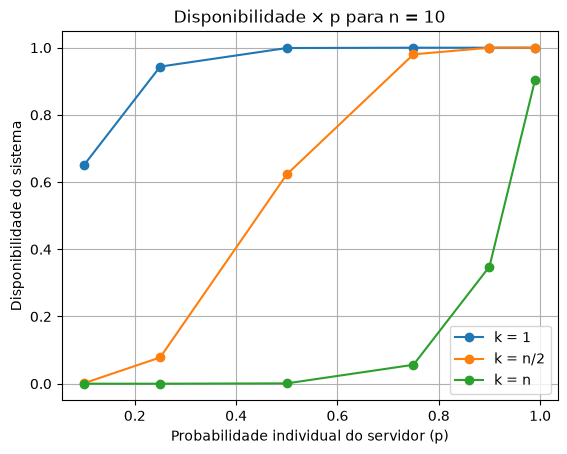

In [25]:
dados = tabela[tabela["n"] == 10]

dados_k1 = dados[dados["k"] == 1]
dados_k_metade = dados[dados["k"] == 5]
dados_kn = dados[dados["k"] == 10]

plt.plot(dados_k1["p"], dados_k1["Resultado"], marker="o", label="k = 1")

plt.plot(dados_k_metade["p"], dados_k_metade["Resultado"], marker="o", label="k = n/2")

plt.plot(dados_kn["p"], dados_kn["Resultado"], marker="o", label="k = n")

plt.xlabel("Probabilidade individual do servidor (p)")
plt.ylabel("Disponibilidade do sistema")
plt.title("Disponibilidade × p para n = 10")

plt.legend()
plt.grid()

plt.show()

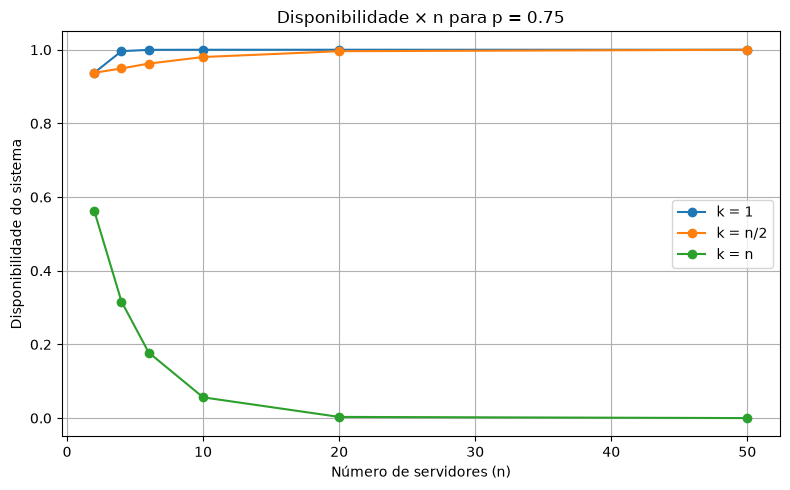

In [26]:
p_grafico = 0.75

dados = tabela[tabela["p"] == p_grafico]
dados_k1 = dados[dados["k"] == 1]
dados_k_metade = dados[dados["k"] == dados["n"] // 2]
dados_kn = dados[dados["k"] == dados["n"]]

plt.figure(figsize=(8, 5))

plt.plot(dados_k1["n"], dados_k1["Resultado"], marker="o", label="k = 1")

plt.plot(dados_k_metade["n"], dados_k_metade["Resultado"], marker="o", label="k = n/2")

plt.plot(dados_kn["n"], dados_kn["Resultado"], marker="o", label="k = n")

plt.xlabel("Número de servidores (n)")
plt.ylabel("Disponibilidade do sistema")
plt.title(f"Disponibilidade × n para p = {p_grafico}")

plt.ylim(-0.05, 1.05)

plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

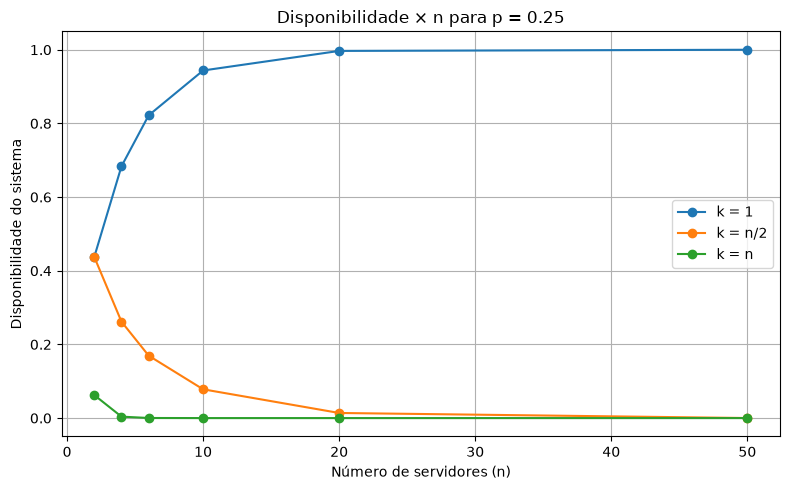

In [27]:
p_escolhido = 0.25

dados = tabela[tabela["p"] == p_escolhido]
dados_k1 = dados[dados["k"] == 1]
dados_k_metade = dados[dados["k"] == dados["n"] // 2]

dados_kn = dados[dados["k"] == dados["n"]]

plt.figure(figsize=(8, 5))

plt.plot(dados_k1["n"], dados_k1["Resultado"], marker="o", label="k = 1")

plt.plot(dados_k_metade["n"], dados_k_metade["Resultado"], marker="o", label="k = n/2")

plt.plot(dados_kn["n"], dados_kn["Resultado"], marker="o", label="k = n")


plt.xlabel("Número de servidores (n)")
plt.ylabel("Disponibilidade do sistema")
plt.title(f"Disponibilidade × n para p = {p_escolhido}")

plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

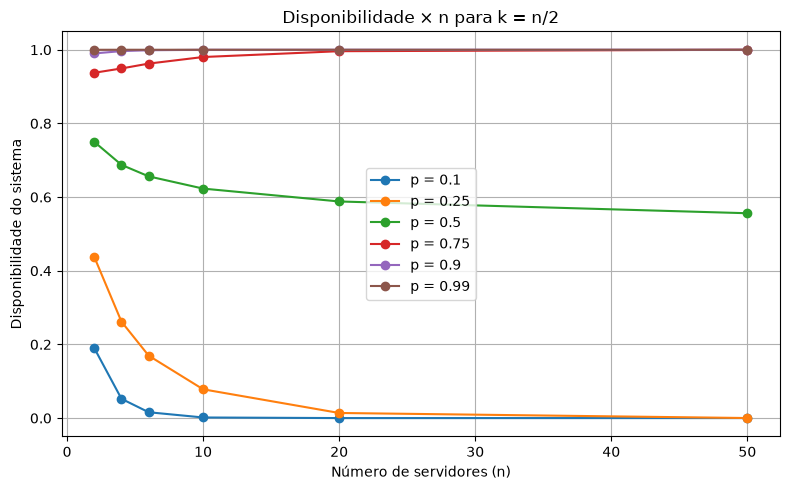

In [28]:
dados = tabela[tabela["k"] == tabela["n"] // 2]

plt.figure(figsize=(8, 5))

for pi in p:
    dados_p = dados[dados["p"] == pi]
    plt.plot(dados_p["n"], dados_p["Resultado"], marker="o", label=f"p = {pi}")

plt.xlabel("Número de servidores (n)")
plt.ylabel("Disponibilidade do sistema")
plt.title("Disponibilidade × n para k = n/2")

plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()